In [21]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 10.0 MB/s eta 0:00:00 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBClassifier
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [61]:
def LoadData(X_filename,Y_filename):
    '''
    Input: Get 2 filenames, 1 for x_data and 1 for y_data
    Output: Two numpy array of X and Y data
    '''
    X = pd.read_csv(X_filename,delimiter=';')
    Y = pd.read_csv(Y_filename,delimiter=';')
    X = X.to_numpy()
    Y = Y.to_numpy()
    return X,Y
    

In [63]:
def SplitTrainTestRandom(X,Y):
    '''
    ***COMPLETED - NO CHANGES ARE REQUIRED***
    
    Input: feature matrix X, labels vector Y
    Output: X_train, Y_train - train data
            X_test, Y_test - test data
    '''
    
    # permute the ordering of the examples
    # random inds every running 
    ind = np.random.permutation(len(Y))
    
    # choose the size of the training data
    Ntrain = int(0.8 * len(Y))
    # split the data into train and test datasets
    
    X_train = X[ind[:Ntrain]]
    Y_train = Y[ind[:Ntrain]]
    X_test  = X[ind[Ntrain:]]
    Y_test  = Y[ind[Ntrain:]]
    
    return X_train, Y_train, X_test, Y_test

In [65]:
def GetFeatureNames(X_filename):
    X = pd.read_csv(X_filename,delimiter=';')
    feature_names = X.columns
    return feature_names

## Parameters Check

### n_estimators check

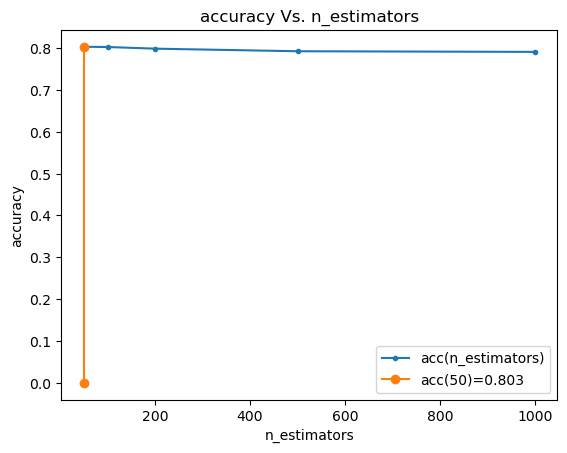

In [71]:
X,Y = LoadData("X_data.csv","Y_data.csv")
running_run = 30
n_estimators_array = np.array([50,100,200,500,1000])
param = 'n_estimators'
model = XGBClassifier()
acc_total = np.array([])

for val in n_estimators_array:
    acc = np.array([])
    model.set_params(n_estimators = val)
    for k in range(running_run):
        X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
        model.fit(X_train,Y_train)
        acc = np.append(acc,model.score(X_test,Y_test))
    acc_total = np.append(acc_total,acc.mean())

# Accruacy plot
plt.plot(n_estimators_array,acc_total,'.-')
plt.plot([n_estimators_array[acc_total.argmax()],n_estimators_array[acc_total.argmax()]],[0,acc_total.max()],'-o')
plt.xlabel(param)
plt.ylabel('accuracy')
plt.title(f'accuracy Vs. {param}')    
plt.legend([f'acc({param})',f'acc({n_estimators_array[acc_total.argmax()]})={np.round(acc_total.max(),3)}'])
plt.show()

### max_depth check

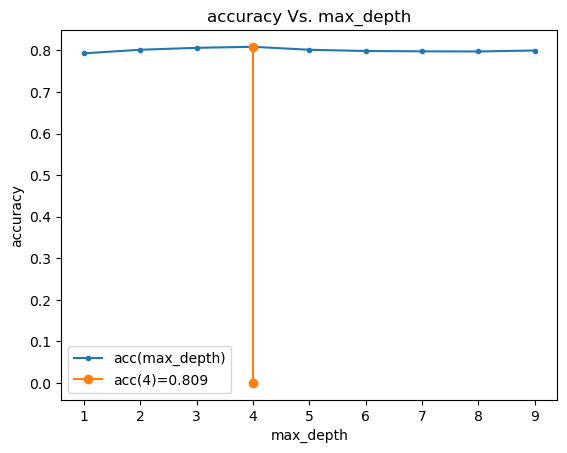

In [75]:
X,Y = LoadData("X_data.csv","Y_data.csv")
running_run = 30
max_depth_array = np.arange(1,10,1)
param = 'max_depth'
model = XGBClassifier()
acc_total = np.array([])

for val in max_depth_array:
    acc = np.array([])
    model.set_params(max_depth = val)
    for k in range(running_run):
        X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
        model.fit(X_train,Y_train)
        acc = np.append(acc,model.score(X_test,Y_test))
    acc_total = np.append(acc_total,acc.mean())

# Accruacy plot
plt.plot(max_depth_array,acc_total,'.-')
plt.plot([max_depth_array[acc_total.argmax()],max_depth_array[acc_total.argmax()]],[0,acc_total.max()],'-o')
plt.xlabel(param)
plt.ylabel('accuracy')
plt.title(f'accuracy Vs. {param}')    
plt.legend([f'acc({param})',f'acc({max_depth_array[acc_total.argmax()]})={np.round(acc_total.max(),3)}'])
plt.show()

### learning_rate check

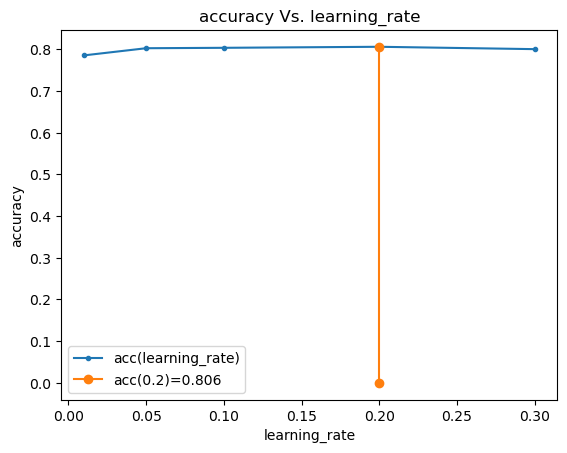

In [77]:
X,Y = LoadData("X_data.csv","Y_data.csv")
running_run = 30
learning_rate_array = np.array([0.01,0.05,0.1,0.2,0.3])
param = 'learning_rate'
model = XGBClassifier()
acc_total = np.array([])

for val in learning_rate_array:
    acc = np.array([])
    model.set_params(learning_rate = val)
    for k in range(running_run):
        X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
        model.fit(X_train,Y_train)
        acc = np.append(acc,model.score(X_test,Y_test))
    acc_total = np.append(acc_total,acc.mean())

# Accruacy plot
plt.plot(learning_rate_array,acc_total,'.-')
plt.plot([learning_rate_array[acc_total.argmax()],learning_rate_array[acc_total.argmax()]],[0,acc_total.max()],'-o')
plt.xlabel(param)
plt.ylabel('accuracy')
plt.title(f'accuracy Vs. {param}')    
plt.legend([f'acc({param})',f'acc({learning_rate_array[acc_total.argmax()]})={np.round(acc_total.max(),3)}'])
plt.show()

In [97]:
np.std(acc_total)

0.0018307035203131167

### min_child_weight check

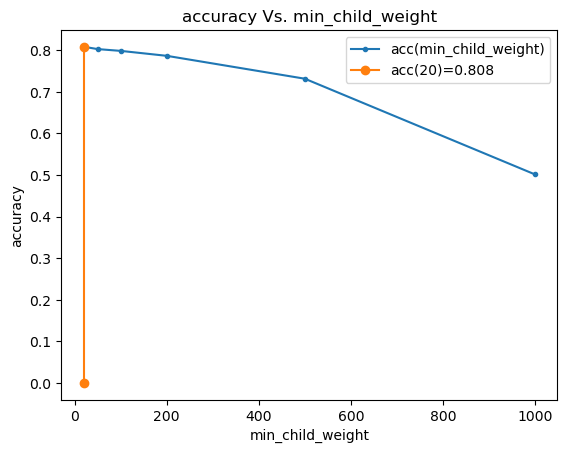

In [121]:
X,Y = LoadData("X_data.csv","Y_data.csv")
running_run = 30
min_child_weight_array = np.array([20,50,100,200,500,1000])
param = 'min_child_weight'
model = XGBClassifier()
acc_total = np.array([])

for val in min_child_weight_array:
    acc = np.array([])
    model.set_params(min_child_weight = val)
    for k in range(running_run):
        X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
        model.fit(X_train,Y_train)
        acc = np.append(acc,model.score(X_test,Y_test))
    acc_total = np.append(acc_total,acc.mean())

# Accruacy plot
plt.plot(min_child_weight_array,acc_total,'.-')
plt.plot([min_child_weight_array[acc_total.argmax()],min_child_weight_array[acc_total.argmax()]],[0,acc_total.max()],'-o')
plt.xlabel(param)
plt.ylabel('accuracy')
plt.title(f'accuracy Vs. {param}')    
plt.legend([f'acc({param})',f'acc({min_child_weight_array[acc_total.argmax()]})={np.round(acc_total.max(),3)}'])
plt.show()

In [137]:
np.std(acc_total)

0.26681574026100296

### gamma check

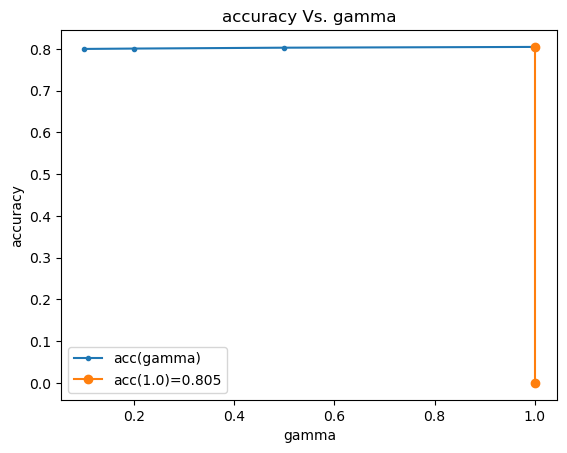

In [85]:
X,Y = LoadData("X_data.csv","Y_data.csv")
running_run = 30
gamma_array = np.array([0.1,0.2,0.5,1])
param = 'gamma'
model = XGBClassifier()
acc_total = np.array([])

for val in gamma_array:
    acc = np.array([])
    model.set_params(gamma = val)
    for k in range(running_run):
        X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
        model.fit(X_train,Y_train)
        acc = np.append(acc,model.score(X_test,Y_test))
    acc_total = np.append(acc_total,acc.mean())

# Accruacy plot
plt.plot(gamma_array,acc_total,'.-')
plt.plot([gamma_array[acc_total.argmax()],gamma_array[acc_total.argmax()]],[0,acc_total.max()],'-o')
plt.xlabel(param)
plt.ylabel('accuracy')
plt.title(f'accuracy Vs. {param}')    
plt.legend([f'acc({param})',f'acc({gamma_array[acc_total.argmax()]})={np.round(acc_total.max(),3)}'])
plt.show()

In [87]:
np.std(acc_total)

0.0018707860216432154

### subsample check

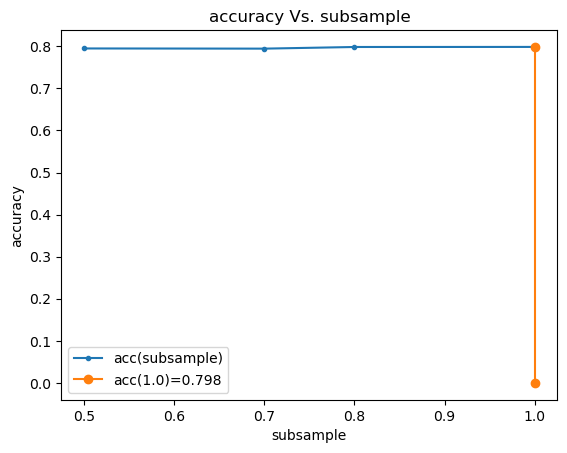

In [89]:
X,Y = LoadData("X_data.csv","Y_data.csv")
running_run = 30
subsample_array = np.array([0.5,0.7,0.8,1])
param = 'subsample'
model = XGBClassifier()
acc_total = np.array([])

for val in subsample_array:
    acc = np.array([])
    model.set_params(subsample = val)
    for k in range(running_run):
        X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
        model.fit(X_train,Y_train)
        acc = np.append(acc,model.score(X_test,Y_test))
    acc_total = np.append(acc_total,acc.mean())

# Accruacy plot
plt.plot(subsample_array,acc_total,'.-')
plt.plot([subsample_array[acc_total.argmax()],subsample_array[acc_total.argmax()]],[0,acc_total.max()],'-o')
plt.xlabel(param)
plt.ylabel('accuracy')
plt.title(f'accuracy Vs. {param}')
plt.legend([f'acc({param})',f'acc({subsample_array[acc_total.argmax()]})={np.round(acc_total.max(),3)}'])
plt.show()

In [91]:
np.std(acc_total)

0.0018943155502290814

### example check

In [ ]:
X,Y = LoadData("X_data.csv","Y_data.csv")
running_num = 30
[]_array = np.array([])
param = '[]'
model = XGBClassifier()
acc_total = np.array([])

for val in []_array:
    acc = np.array([])
    model.set_params([] = val)
    for k in range(running_num):
        X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
        model.fit(X_train,Y_train)
        acc = np.append(acc,model.score(X_test,Y_test))
    acc_total = np.append(acc_total,acc.mean())

# Accruacy plot
plt.plot([]_array,acc_total,'.-')
plt.plot([[]_array[acc_total.argmax()],[]_array[acc_total.argmax()]],[0,acc_total.max()],'-o')
plt.xlabel(param)
plt.ylabel('accuracy')
plt.title(f'accuracy Vs. {param}')    
plt.legend([f'acc({param})',f'acc({[]_array[acc_total.argmax()]})={np.round(acc_total.max(),3)}'])
plt.show()

## optimum parameters check

In [145]:
X,Y = LoadData("X_data.csv","Y_data.csv")
running_num = 40
acc = np.array([])
for i in range(running_num):
    X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
    model = XGBClassifier()
    model.set_params(n_estimators=250 ,max_depth=3,learning_rate=0.0825,gamma=1,subsample=0.6)
    model.fit(X_train,Y_train)
    acc = np.append(acc,model.score(X_test,Y_test))
acc.mean()

0.8073599523241954

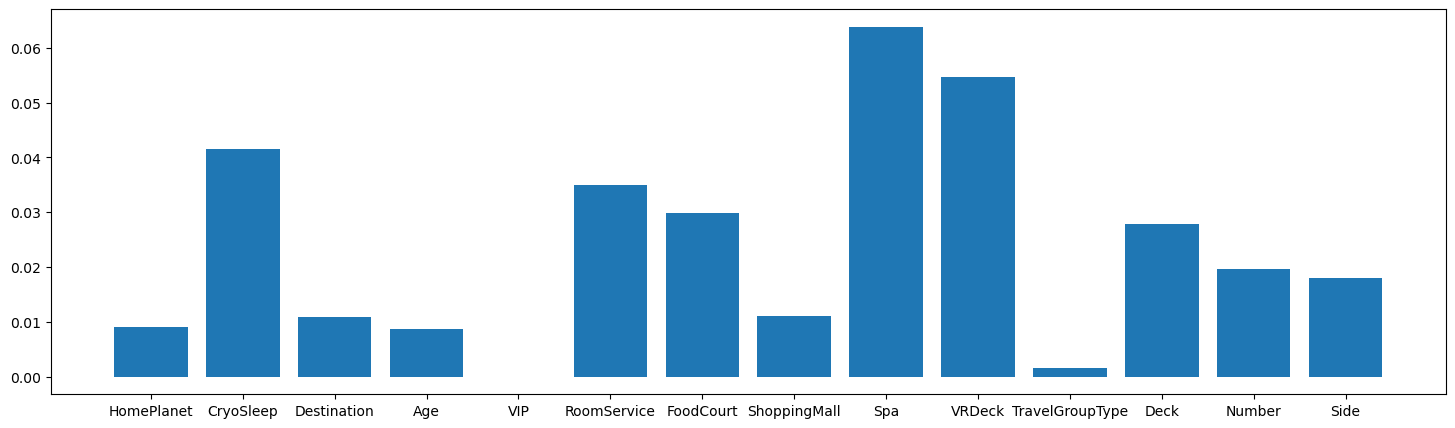

In [149]:
from sklearn.inspection import permutation_importance
feature_names = GetFeatureNames("X_data.csv")
result = permutation_importance(model, X_test, Y_test, n_repeats=30, random_state=42)
importances = result.importances_mean

plt.figure(figsize=(18,5))
plt.bar(range(len(importances)), importances) 
plt.xticks(ticks=range(len(feature_names)),labels=feature_names)
plt.show()